# Tugas 5 Ringkasan Dokumen

#### Rafly Faldiansyah Putra
#### 210411100063
#### PPW A

In [18]:
import string
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import csv

# URL dari artikel Berita di IDN Times
url = 'https://nasional.kompas.com/read/2024/11/02/18560111/prabowo-ingin-ri-tak-jadi-negara-papan-bawah-kita-tidak-miskin'

# Membuat permintaan ke URL
response = requests.get(url)

# Inisialisasi data yang akan disimpan
# Mengambil ulang dan membersihkan data yang diminta
artikel_mees = []

if response.status_code == 200:
    # Parsing halaman web
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Mengambil judul artikel
    title = soup.find('h1').get_text().strip()
    
    # Mengambil tanggal publikasi artikel dan membersihkan spasi berlebih

    date_tag = soup.find('div', class_='videoKG-date')
    if not date_tag:
        # Jika tidak ditemukan, ambil dari div dengan class 'read__time'
        date_tag = soup.find('div', class_='read__time')
    
    date = date_tag.text.strip().split('-')[-1].strip() if date_tag else 'Tidak ada tanggal'
    
    # Mengambil isi artikel dengan membersihkan konten tambahan
    content_div = soup.find('div', class_='read__content')
    article_text = ' '.join([p.text for p in content_div.find_all('p')]) if content_div else 'Tidak ada isi berita'

    # Simpan data dalam bentuk dictionary yang telah dibersihkan
    artikel_mees.append({
        'Title': title,
        'Date': date,
        'Content': article_text
    })

# Membuat dataframe dari data yang telah dibersihkan
data_mees = pd.DataFrame(artikel_mees)

# Menampilkan dataframe yang bersih
data_mees

,Title,Date,Content
0,Prabowo Ingin RI Tak Jadi Negara Papan Bawah: ...,"02/11/2024, 18:56 WIB","JAKARTA, KOMPAS.com - Presiden Prabowo Subiant..."


In [2]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# Proses case folding
def casefolding(Content):
    if isinstance(Content, list):
        # Jika Content adalah list, terapkan case folding pada setiap elemen
        return [str(item).lower() for item in Content]
    else:
        # Jika Content adalah string, langsung terapkan case folding
        return str(Content).lower()

# Terapkan fungsi casefolding pada kolom 'Content'
data_mees['Content'] = data_mees['Content'].apply(casefolding)

data_mees.head()

,Title,Date,Content
0,Prabowo Ingin RI Tak Jadi Negara Papan Bawah: ...,"02/11/2024, 18:56 WIB","jakarta, kompas.com - presiden prabowo subiant..."


In [4]:
csv_filename = "artikel_idn.csv"
data_mees.to_csv(csv_filename, index=False, encoding='utf-8')

print(f"Data berita telah disimpan ke {csv_filename}")

Data berita telah disimpan ke artikel_idn.csv


In [5]:
data_mees = pd.read_csv("artikel_idn.csv", sep=',', encoding='latin1')
data_mees.head()

,Title,Date,Content
0,Prabowo Ingin RI Tak Jadi Negara Papan Bawah: ...,"02/11/2024, 18:56 WIB","jakarta, kompas.com - presiden prabowo subiant..."


In [6]:
def cleansing(Content):
    # Menghapus whitespace di awal dan akhir teks
    Content = Content.strip()
    
    # Menghapus tanda baca dan karakter khusus
    Content = re.sub(f"[{string.punctuation}]", '', Content)
    
    # Menghapus angka
    Content = re.sub(r'\d+', '', Content)
    
    # Menghapus huruf tunggal (opsional, tergantung kebutuhan)
    Content = re.sub(r"\b[a-zA-Z]\b", "", Content)
    
    # Menghapus karakter-karakter non-standar seperti â
    Content = re.sub(r'[^\x00-\x7F]+', '', Content)
    
    # Menghapus spasi ganda
    Content = re.sub(r'\s+', ' ', Content)
    
    return Content

# Terapkan fungsi cleansing pada kolom 'Content'
data_mees['Content'] = data_mees['Content'].apply(cleansing)

# Menampilkan 5 baris pertama
data_mees.head(5)

,Title,Date,Content
0,Prabowo Ingin RI Tak Jadi Negara Papan Bawah: ...,"02/11/2024, 18:56 WIB",jakarta kompascom presiden prabowo subianto ti...


In [7]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rafly\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
import pandas as pd  # Ensure you import pandas for DataFrame usage

# Download required resources
nltk.download('punkt')
nltk.download('punkt_tab')

# Assume article_text is defined; replace with your actual text
# article_text = "Your article text goes here."

# Ekstraksi kalimat dari konten artikel
sentences = sent_tokenize(article_text)

# Tokenisasi tiap kalimat menjadi term
terms_per_sentence = [word_tokenize(sentence) for sentence in sentences]

# Membuat objek yang menyimpan hasil term dari setiap kalimat
extracted_terms = [{'Sentence': sentence, 'Terms': terms} for sentence, terms in zip(sentences, terms_per_sentence)]

# Menampilkan hasilnya sebagai dataframe
df_terms = pd.DataFrame(extracted_terms)

# Menampilkan dataframe
print(df_terms)


                                             Sentence  \
0   JAKARTA, KOMPAS.com - Presiden Prabowo Subiant...   
1   Ia justru ingin melihat Indonesia menjadi bang...   
2   Hal ini dikatakan Prabowo saat menyampaikan sa...   
3     "Kita tidak mau jadi selalu negara papan bawah.   
4   Kita tidak mau diangggap selalu bangsa yang mi...   
5   Karena kita tahu bahwa kita tidak miskin, kita...   
6   Oleh karenanya, ia mengajak seluruh tim sukses...   
7     Ia tidak ingin mereka tercerai-berai dan bubar.   
8   Baca juga: Kala Prabowo Minta Wiranto hingga A...   
9   Prabowo lantas menceritakan peradaban dunia ya...   
10  Saat itu, peradabannya berjaya dan menjadi kib...   
11  Pun pemerintahannya bersih dan sesuai dengan a...   
12  Ia pun menyatakan, tidak ada negara yang berha...   
13  Baca juga: Prabowo Ingin Timsesnya di Pilpres ...   
14               Tidak ada kemakmuran tanpa keadilan.   
15  Tidak ada negara yang berhasil kalau rakyatnya...   
16       Ini ajaran sejarah rat

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rafly\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Rafly\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
csv_filename = "artikel_mees_hilgers_ekstract_term.csv"
df_terms.to_csv(csv_filename, index=False, encoding='utf-8')

print(f"Data berita telah disimpan ke {csv_filename}")

Data berita telah disimpan ke artikel_mees_hilgers_ekstract_term.csv


In [10]:
pip install Sastrawi

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import sent_tokenize, word_tokenize

# Assuming we have the article_text
sentences = sent_tokenize(article_text)
terms_per_sentence = [word_tokenize(sentence) for sentence in sentences]
extracted_terms = [{'Sentence': sentence, 'Terms': terms} for sentence, terms in zip(sentences, terms_per_sentence)]
df_terms = pd.DataFrame(extracted_terms)

# Menggabungkan terms menjadi string untuk setiap kalimat
df_terms['Terms_String'] = df_terms['Terms'].apply(' '.join)

# Membuat TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit dan transform data
tfidf_matrix = tfidf_vectorizer.fit_transform(df_terms['Terms_String'])

# Mendapatkan nama-nama feature (terms)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Membuat DataFrame untuk nilai TF-IDF
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# Menambahkan kolom Sentence
tfidf_df['Sentence'] = df_terms['Sentence']

# Melelehkan (melting) DataFrame untuk format yang lebih mudah dibaca
melted_tfidf = tfidf_df.melt(id_vars=['Sentence'], var_name='Term', value_name='TF-IDF')

# Menghapus baris dengan nilai TF-IDF 0
melted_tfidf = melted_tfidf[melted_tfidf['TF-IDF'] != 0]

# Mengurutkan berdasarkan nilai TF-IDF tertinggi
melted_tfidf = melted_tfidf.sort_values('TF-IDF', ascending=False)

# Menampilkan hasil
print(melted_tfidf)

                                               Sentence        Term    TF-IDF
2545                                         tandasnya.   tandasnya  1.000000
1373  Karena kita tahu bahwa kita tidak miskin, kita...        kita  0.628664
1344               Tidak ada kemakmuran tanpa keadilan.  kemakmuran  0.563438
2259  "Karena itu saya bertekad, saya bertekad memim...        saya  0.555807
473   "Karena itu saya bertekad, saya bertekad memim...    bertekad  0.555807
...                                                 ...         ...       ...
863   Baca juga: Kala Prabowo Minta Wiranto hingga A...         gsn  0.094248
958   Baca juga: Kala Prabowo Minta Wiranto hingga A...   indonesia  0.086188
730   Baca juga: Kala Prabowo Minta Wiranto hingga A...          di  0.086188
1813  Baca juga: Kala Prabowo Minta Wiranto hingga A...      negara  0.074035
2801  Baca juga: Kala Prabowo Minta Wiranto hingga A...        yang  0.061153

[239 rows x 3 columns]


In [12]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine

# Assuming we have the melted_tfidf DataFrame from the previous code
# If not, uncomment and run the previous code to get melted_tfidf

# Step 1: Pivot the melted DataFrame back to wide format
tfidf_wide = melted_tfidf.pivot(index='Sentence', columns='Term', values='TF-IDF').fillna(0)

# Step 2: Calculate cosine similarity between sentences
num_sentences = len(tfidf_wide)
adjacency_matrix = np.zeros((num_sentences, num_sentences))

for i in range(num_sentences):
    for j in range(i, num_sentences):  # We only need to calculate upper triangle
        if i == j:
            adjacency_matrix[i][j] = 1.0  # Sentence is fully similar to itself
        else:
            similarity = 1 - cosine(tfidf_wide.iloc[i], tfidf_wide.iloc[j])
            adjacency_matrix[i][j] = similarity
            adjacency_matrix[j][i] = similarity  # Matrix is symmetric

# Create a DataFrame for better visualization
adjacency_df = pd.DataFrame(adjacency_matrix, 
                            index=tfidf_wide.index, 
                            columns=tfidf_wide.index)

# Display the adjacency matrix
print("Adjacency Matrix:")
print(adjacency_df)

# Optional: You can set a threshold to consider only strong connections
threshold = 0.5
adjacency_df_thresholded = adjacency_df.where(adjacency_df > threshold, 0)

print("\nAdjacency Matrix (with threshold):")
print(adjacency_df_thresholded)

# Optional: Save to CSV
adjacency_df.to_csv('adjacency_matrix.csv')
adjacency_df_thresholded.to_csv('adjacency_matrix_thresholded.csv')

Adjacency Matrix:
Sentence                                            "Karena itu saya bertekad, saya bertekad memimpin pemerintah RI yang bersih!"  \
Sentence                                                                                                                            
"Karena itu saya bertekad, saya bertekad memimp...                                           1.000000                               
"Kita tidak mau jadi selalu negara papan bawah.                                              0.000000                               
Baca juga: Kala Prabowo Minta Wiranto hingga AH...                                           0.070797                               
Baca juga: Prabowo Ingin Timsesnya di Pilpres T...                                           0.128463                               
Hal ini dikatakan Prabowo saat menyampaikan sam...                                           0.000000                               
Ia justru ingin melihat Indonesia menjadi bangs... 

In [13]:
# Step 3: Convert cosine similarity to binary values (0 or 1) based on threshold
binary_threshold = 0.5
adjacency_df_binary = adjacency_df.applymap(lambda x: 1 if x >= binary_threshold else 0)

print("\nAdjacency Matrix (binary, based on threshold):")
print(adjacency_df_binary)

# Optional: Save the binary adjacency matrix to CSV
adjacency_df_binary.to_csv('adjacency_matrix_binary.csv')



Adjacency Matrix (binary, based on threshold):
Sentence                                            "Karena itu saya bertekad, saya bertekad memimpin pemerintah RI yang bersih!"  \
Sentence                                                                                                                            
"Karena itu saya bertekad, saya bertekad memimp...                                                  1                               
"Kita tidak mau jadi selalu negara papan bawah.                                                     0                               
Baca juga: Kala Prabowo Minta Wiranto hingga AH...                                                  0                               
Baca juga: Prabowo Ingin Timsesnya di Pilpres T...                                                  0                               
Hal ini dikatakan Prabowo saat menyampaikan sam...                                                  0                               
Ia justru ingin melih

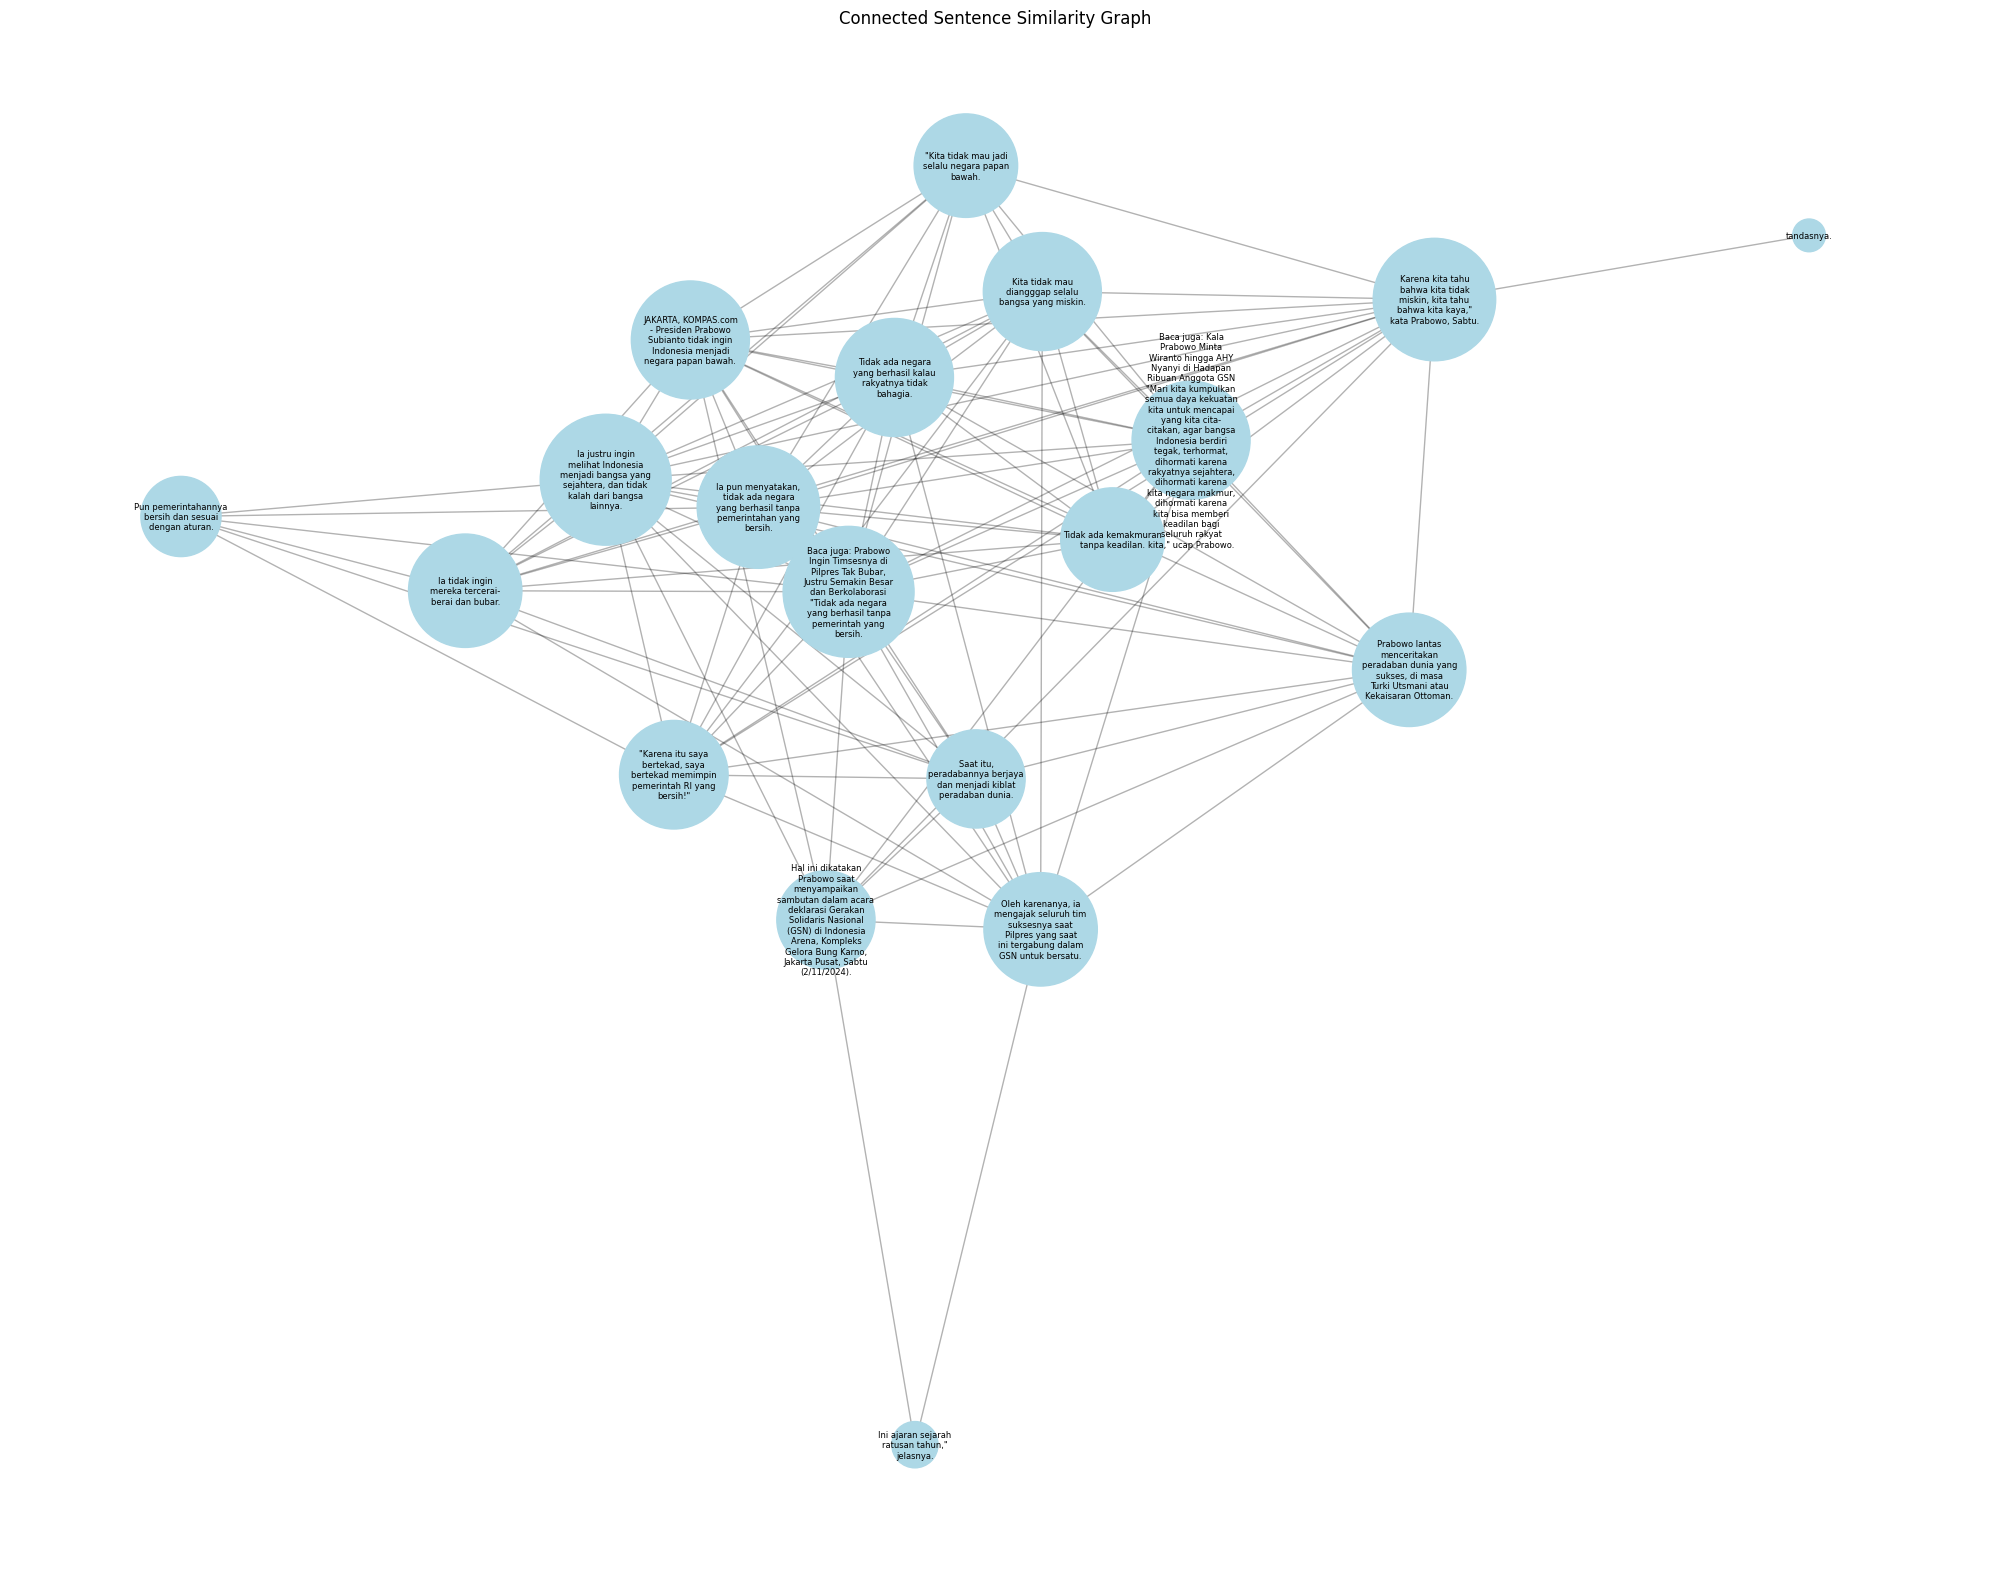

Number of nodes: 19
Number of edges: 103
Is the graph connected? True

Centrality Measures:
                                             Sentence  Degree Centrality  \
3   Baca juga: Prabowo Ingin Timsesnya di Pilpres ...           0.888889   
5   Ia justru ingin melihat Indonesia menjadi bang...           0.888889   
6   Ia pun menyatakan, tidak ada negara yang berha...           0.777778   
10  Karena kita tahu bahwa kita tidak miskin, kita...           0.777778   
9   JAKARTA, KOMPAS.com - Presiden Prabowo Subiant...           0.722222   
11  Kita tidak mau diangggap selalu bangsa yang mi...           0.722222   
2   Baca juga: Kala Prabowo Minta Wiranto hingga A...           0.722222   
17  Tidak ada negara yang berhasil kalau rakyatnya...           0.722222   
7     Ia tidak ingin mereka tercerai-berai dan bubar.           0.666667   
13  Prabowo lantas menceritakan peradaban dunia ya...           0.666667   
12  Oleh karenanya, ia mengajak seluruh tim sukses...           0.666667

In [14]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import textwrap

# Assuming we have the tfidf_wide DataFrame and original sentences from previous steps
# If not, you need to run the TF-IDF calculation code first

# Calculate cosine similarity
cosine_sim = cosine_similarity(tfidf_wide)

# Create a DataFrame for the similarity matrix
similarity_df = pd.DataFrame(cosine_sim, index=tfidf_wide.index, columns=tfidf_wide.index)

# Create a graph from the similarity matrix
G = nx.from_pandas_adjacency(similarity_df)

# Remove self-loops
G.remove_edges_from(nx.selfloop_edges(G))

# Function to get the largest connected component
def get_largest_component(G):
    return max(nx.connected_components(G), key=len)

# Ensure the graph is connected
while not nx.is_connected(G):
    largest_component = get_largest_component(G)
    isolated_nodes = set(G.nodes()) - set(largest_component)
    if not isolated_nodes:
        break
    for node in isolated_nodes:
        similarities = [(other_node, similarity_df.loc[node, other_node]) 
                        for other_node in largest_component]
        most_similar_node = max(similarities, key=lambda x: x[1])[0]
        G.add_edge(node, most_similar_node)

# Function to wrap text
def wrap_text(text, width=20):
    return '\n'.join(textwrap.wrap(text, width=width))

# Prepare labels (wrapped sentences)
labels = {node: wrap_text(node) for node in G.nodes()}

# Now let's visualize the graph
plt.figure(figsize=(20, 16))  # Increased figure size
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Calculate node sizes based on degree centrality
degree_centrality = nx.degree_centrality(G)
node_sizes = [v * 10000 for v in degree_centrality.values()]  # Increased node sizes

# Draw the graph
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue')
nx.draw_networkx_edges(G, pos, alpha=0.3)

# Add labels
nx.draw_networkx_labels(G, pos, labels, font_size=6)  # Reduced font size

plt.title("Connected Sentence Similarity Graph")
plt.axis('off')
plt.tight_layout()

# Save the graph as an image
plt.savefig('connected_sentence_similarity_graph.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# Print some information about the graph
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is the graph connected? {nx.is_connected(G)}")

# Calculate centrality measures
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# Create a DataFrame with centrality measures
centrality_data = []
for node in G.nodes():
    centrality_data.append({
        'Sentence': node,
        'Degree Centrality': degree_centrality[node],
        'Closeness Centrality': closeness_centrality[node],
        'Betweenness Centrality': betweenness_centrality[node]
    })

centrality_df = pd.DataFrame(centrality_data)

# Sort by Degree Centrality
centrality_df = centrality_df.sort_values('Degree Centrality', ascending=False)

print("\nCentrality Measures:")
print(centrality_df)

# Save centrality measures to CSV
centrality_df.to_csv('centrality_measures_with_sentences.csv', index=False)

# Optionally, print the top 5 sentences by each centrality measure
print("\nTop 5 sentences by Degree Centrality:")
print(centrality_df.nlargest(5, 'Degree Centrality')[['Sentence', 'Degree Centrality']])

print("\nTop 5 sentences by Closeness Centrality:")
print(centrality_df.nlargest(5, 'Closeness Centrality')[['Sentence', 'Closeness Centrality']])

print("\nTop 5 sentences by Betweenness Centrality:")
print(centrality_df.nlargest(5, 'Betweenness Centrality')[['Sentence', 'Betweenness Centrality']])

In [16]:
import pandas as pd

def summarize_document(melted_tfidf, num_sentences=3):

    # Hitung total TF-IDF untuk setiap kalimat
    tfidf_per_sentence = melted_tfidf.groupby('Sentence')['TF-IDF'].sum()

    # Pilih kalimat dengan skor TF-IDF tertinggi
    top_sentences = tfidf_per_sentence.nlargest(num_sentences)

    # Mendapatkan kalimat ringkasan
    summary_sentences = top_sentences.index.tolist()

    return summary_sentences

# Menentukan jumlah kalimat untuk ringkasan (misalnya, 5 kalimat)
num_sentences = 5
summary = summarize_document(melted_tfidf, num_sentences=num_sentences)

# Menampilkan hasil ringkasan
print("Ringkasan Dokumen:")
for idx, sentence in enumerate(summary, 1):
    print(f"{idx}. {sentence}")


Ringkasan Dokumen:
1. Baca juga: Kala Prabowo Minta Wiranto hingga AHY Nyanyi di Hadapan Ribuan Anggota GSN "Mari kita kumpulkan semua daya kekuatan kita untuk mencapai yang kita cita-citakan, agar bangsa Indonesia berdiri tegak, terhormat, dihormati karena rakyatnya sejahtera, dihormati karena kita negara makmur, dihormati karena kita bisa memberi keadilan bagi seluruh rakyat kita," ucap Prabowo.
2. Hal ini dikatakan Prabowo saat menyampaikan sambutan dalam acara deklarasi Gerakan Solidaris Nasional (GSN) di Indonesia Arena, Kompleks Gelora Bung Karno, Jakarta Pusat, Sabtu (2/11/2024).
3. Baca juga: Prabowo Ingin Timsesnya di Pilpres Tak Bubar, Justru Semakin Besar dan Berkolaborasi "Tidak ada negara yang berhasil tanpa pemerintah yang bersih.
4. Oleh karenanya, ia mengajak seluruh tim suksesnya saat Pilpres yang saat ini tergabung dalam GSN untuk bersatu.
5. Prabowo lantas menceritakan peradaban dunia yang sukses, di masa Turki Utsmani atau Kekaisaran Ottoman.


## Link App Meringkas Dokumen :
### https://huggingface.co/spaces/Raflyyy/Summarizer-News